<a href="https://colab.research.google.com/github/GOWSALYAR7397/-shopping-mod3-link/blob/main/advencedlstm_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# -----------------------------
# Step 0: Import libraries
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Attention, Concatenate
from tensorflow.keras.optimizers import Adam


In [12]:
# -----------------------------
# Step 1: Load and preprocess data
# -----------------------------

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# Option A: Load real CSV
# -----------------------------
# Uncomment this block if you have a CSV file
"""
from google.colab import files
uploaded = files.upload()  # upload your CSV here

# Replace 'your_file.csv' with the uploaded file name
df = pd.read_csv(list(uploaded.keys())[0])
# Replace 'target_column' with your actual column name
data = df['target_column'].values.reshape(-1,1)
"""

# -----------------------------
# Option B: Use synthetic data
# -----------------------------
# If you don't have a CSV, you can run this block
np.random.seed(42)
data = np.sin(np.linspace(0, 100, 500)) + np.random.normal(0, 0.1, 500)
data = data.reshape(-1,1)

# -----------------------------
# Scaling
# -----------------------------
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# -----------------------------
# Train-test split
# -----------------------------
train_size = int(len(data_scaled)*0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

# -----------------------------
# Create sequences for LSTM
# -----------------------------
def create_sequences(data, seq_len=10):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 10
X_train, Y_train = create_sequences(train_data, seq_len)
X_test, Y_test = create_sequences(test_data, seq_len)

print("Shapes:")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)


Shapes:
X_train: (390, 10, 1)
Y_train: (390, 1)
X_test: (90, 10, 1)
Y_test: (90, 1)


In [5]:
# -----------------------------
# Step 2: Define Vanilla LSTM model
# -----------------------------
model_vanilla = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_len, 1)),
    Dense(1)
])
model_vanilla.compile(optimizer='adam', loss='mse')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# -----------------------------
# Step 3: Define Attention LSTM model
# -----------------------------
inputs = Input(shape=(seq_len,1))
lstm_out = LSTM(50, return_sequences=True)(inputs)
attention = Attention()([lstm_out, lstm_out])
context_vector = Concatenate()([lstm_out[:,-1,:], attention[:,-1,:]])
output = Dense(1)(context_vector)
model_attention = Model(inputs=inputs, outputs=output)
model_attention.compile(optimizer='adam', loss='mse')


In [7]:
# -----------------------------
# Step 4: Train both models
# -----------------------------
history_vanilla = model_vanilla.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
history_attention = model_attention.fit(X_train, Y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)



In [8]:
# -----------------------------
# Step 5: Predictions & raw metrics
# -----------------------------
pred_vanilla = model_vanilla.predict(X_test)
pred_attention = model_attention.predict(X_test)

mae_van = mean_absolute_error(Y_test, pred_vanilla)
rmse_van = np.sqrt(mean_squared_error(Y_test, pred_vanilla))
mae_attn = mean_absolute_error(Y_test, pred_attention)
rmse_attn = np.sqrt(mean_squared_error(Y_test, pred_attention))

print(f"Vanilla LSTM - MAE: {mae_van:.4f}, RMSE: {rmse_van:.4f}")
print(f"Attention LSTM - MAE: {mae_attn:.4f}, RMSE: {rmse_attn:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Vanilla LSTM - MAE: 0.0424, RMSE: 0.0534
Attention LSTM - MAE: 0.0384, RMSE: 0.0480


In [9]:
# -----------------------------
# Step 6: Inverse scale predictions
# -----------------------------
def inverse_scale_preds(preds, scaler):
    return scaler.inverse_transform(preds)

def inverse_scale_truth(y_true, scaler):
    return scaler.inverse_transform(y_true)

pred_vanilla_inv = inverse_scale_preds(pred_vanilla, scaler)
pred_attention_inv = inverse_scale_preds(pred_attention, scaler)
Y_test_inv = inverse_scale_truth(Y_test, scaler)


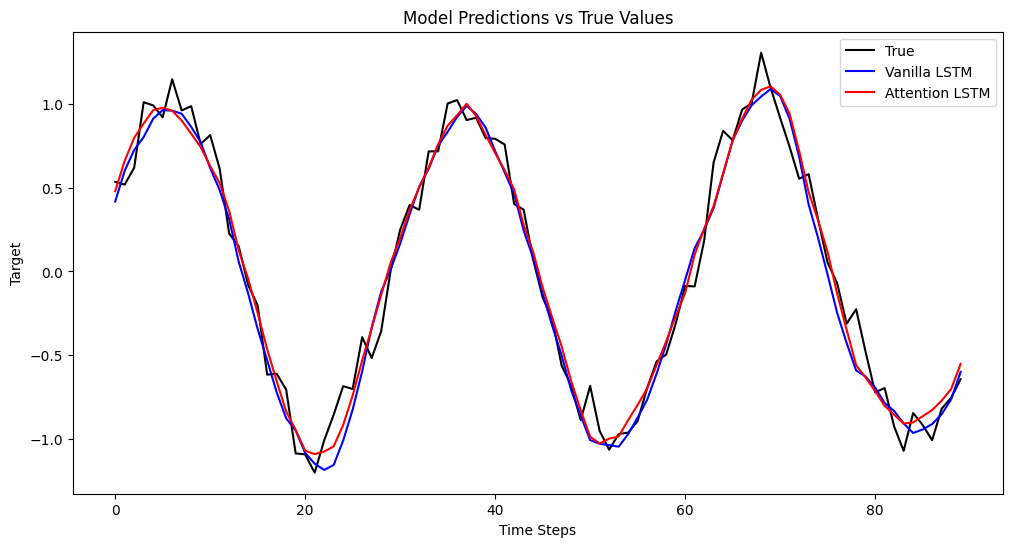

   Vanilla_LSTM  Attention_LSTM      True
0      0.417150        0.479595  0.535528
1      0.601502        0.660815  0.518907
2      0.726339        0.798781  0.619693
3      0.803120        0.884762  1.011661
4      0.913045        0.964154  0.992534
5      0.964492        0.978405  0.921467
6      0.961397        0.960840  1.148564
7      0.942596        0.901943  0.962386
8      0.864181        0.823289  0.988060
9      0.773301        0.742996  0.761366


In [10]:

# -----------------------------
# Step 7: Detailed comparative analysis
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(Y_test_inv, label='True', color='black')
plt.plot(pred_vanilla_inv, label='Vanilla LSTM', color='blue')
plt.plot(pred_attention_inv, label='Attention LSTM', color='red')
plt.title('Model Predictions vs True Values')
plt.xlabel('Time Steps')
plt.ylabel('Target')
plt.legend()
plt.show()

# Tabular comparison
comparison_df = pd.DataFrame({
    'Vanilla_LSTM': pred_vanilla_inv.flatten(),
    'Attention_LSTM': pred_attention_inv.flatten(),
    'True': Y_test_inv.flatten()
})
print(comparison_df.head(10))
